### Systematic comparison of topics across conditions using quantitative similarity measurement

We calculate the semantic similarity between the topics from the two conditions directly from the sentence embedding

1. Create a Single "Topic Vector": For each topic in both HS and DL, calculate its average vector. We do this by taking the sentence embeddings of all sentences assigned to that topic and averaging them. This gives a single vector that represents the semantic center of that topic.

2. Calculate Cosine Similarity: Use cosine similarity to measure the angle between each HS topic vector and each DL topic vector. The output will be a score between 0 and 1*, where 1 means they are semantically identical.

3. Visualise with a Heatmap: Place the HS topics on the Y-axis and the DL topics on the X-axis. The colour of each cell would represent the cosine similarity score between the two topics.



* (with modern sentence embeddings, instead of -1 to 1). This happens because of how models are trained (designed to place sentences with similar meanings closer in the vector space, so vectors they produce tend to exist in the "first quadrant" of the high-dimensional space ie  most of their component values are positive).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import os,sys 
import importlib

#setup paths
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..', '../..'))  # goes two levels up to MOSAIC
print("Project root:",project_root)
sys.path.append(project_root)

#define dataset config
# dataset = "dreamachine"
# condition_1 = "HS"
# condition_2 = "DL"

dataset = "ganzfeld"
condition_1 = "RED"
condition_2 = "GREEN"

use_configs = False

if use_configs:
    try:
        config_module = importlib.import_module(f"configs.{dataset}")
        config = config_module.config
        print(f"Successfully loaded config for: {dataset}")
    except ImportError as e:
        print(f"Error: Could not load config for '{dataset}'. Check if 'configs/{dataset}.py' exists.")
        raise e
    except AttributeError:
        print(f"Error: The file 'configs/{dataset}.py' exists but does not contain a 'config' object.")
        raise
    print("Config:", config)

Project root: /Users/rb666/Projects


In [2]:
results_dir = os.path.join(project_root, "MOSAIC/results")
topic_content_1 = pd.read_csv(os.path.join(results_dir, f"topics_content/{dataset}_{condition_1}_topic_content.csv"))
topic_content_2 = pd.read_csv(os.path.join(results_dir, f"topics_content/{dataset}_{condition_2}_topic_content.csv"))

In [3]:
#print topics in condition 1
print(f"Topics in condition {condition_1}:")
list(topic_content_1.topic_name)

Topics in condition RED:


['Perceiving variable light color intensity',
 'Perceiving absence of human communication',
 'Transition to a state of drowsiness',
 'Loss of temporal awareness',
 'Perceiving different emotional states under varying conditions',
 'Clear mental space and focused thinking',
 'Sense of oppressive bodily confinement',
 'Perception of time duration variability']

In [4]:

print(f"Topics in condition {condition_2}:")
list(topic_content_2.topic_name)

Topics in condition GREEN:


['Perceiving intense and changing visual stimuli',
 'Transition between wakefulness and sleep',
 'Continuous mental activity',
 'Perceiving indistinct auditory patterns',
 'Uncertainty about duration of experience',
 'Perceiving dynamic, ambiguous, and fantastical visual patterns',
 'Uncertainty about a specific event']

In [5]:
#check the names of the columns in topic_content
print(topic_content_2.columns)

topic_content_1['Sentence_Count'] = topic_content_1['texts'].apply(lambda x: len(x.split(' | ')) if isinstance(x, str) else 0)
topic_content_2['Sentence_Count'] = topic_content_2['texts'].apply(lambda x: len(x.split(' | ')) if isinstance(x, str) else 0)

Index(['Topic', 'topic_name', 'report_ids', 'texts'], dtype='object')


# Method 1

In [6]:
df_cond1 = topic_content_1
df_cond2 = topic_content_2

cond1_counts = df_cond1.set_index('topic_name')['Sentence_Count'].rename(condition_1)
cond2_counts = df_cond2.set_index('topic_name')['Sentence_Count'].rename(condition_2)

contingency_table = pd.concat([cond1_counts, cond2_counts], axis=1).fillna(0).astype(int)

if 'Outlier' in contingency_table.index:
    contingency_table = contingency_table.drop('Outlier')

if 'Unlabelled' in contingency_table.index:
    contingency_table = contingency_table.drop('Unlabelled')

print("\n--- Contingency Table (Observed Frequencies) ---")
print(contingency_table)
print("-------------------------------------------------")


--- Contingency Table (Observed Frequencies) ---
                                                    RED  GREEN
topic_name                                                    
Perceiving variable light color intensity            51      0
Perceiving absence of human communication            39      0
Transition to a state of drowsiness                  37      0
Loss of temporal awareness                           30      0
Perceiving different emotional states under var...   29      0
Clear mental space and focused thinking              29      0
Sense of oppressive bodily confinement               27      0
Perception of time duration variability              17      0
Perceiving intense and changing visual stimuli        0     55
Transition between wakefulness and sleep              0     47
Continuous mental activity                            0     28
Perceiving indistinct auditory patterns               0     25
Uncertainty about duration of experience              0     21
Perce

# Method 2

In [7]:
# Condition 1
df1_full = topic_content_1.copy()
df1_full['texts'] = df1_full['texts'].apply(lambda x: x.split(' | ') if isinstance(x, str) else [])
df1_full = df1_full.explode('texts').reset_index(drop=True)
df1_full = df1_full.rename(columns={'topic_name': 'topic', 'texts': 'text'})
df1_full = df1_full[['topic', 'text']]

# Condition 2
df2_full = topic_content_2.copy()
df2_full['texts'] = df2_full['texts'].apply(lambda x: x.split(' | ') if isinstance(x, str) else [])
df2_full = df2_full.explode('texts').reset_index(drop=True)
df2_full = df2_full.rename(columns={'topic_name': 'topic', 'texts': 'text'})
df2_full = df2_full[['topic', 'text']]

print(df1_full.head())
print(df2_full.head())

                                       topic  \
0  Perceiving variable light color intensity   
1  Perceiving variable light color intensity   
2  Perceiving variable light color intensity   
3  Perceiving variable light color intensity   
4  Perceiving variable light color intensity   

                                                text  
0  And also, I'm not sure if it was influenced by...  
1  At the level of colors and shapes, well, yes, ...  
2  Finally... knowing that I had the red LED in f...  
3  That thing with the light is funny: at first, ...  
4  I have the impression that there's no color left.  
                                            topic  \
0  Perceiving intense and changing visual stimuli   
1  Perceiving intense and changing visual stimuli   
2  Perceiving intense and changing visual stimuli   
3  Perceiving intense and changing visual stimuli   
4  Perceiving intense and changing visual stimuli   

                                                text  
0  Mayb

### Generate sentence embeddings

In [8]:
# Load a pre-trained model
try:
    model = SentenceTransformer(config.transformer_model)
except:
    model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B")

print(f"\n--- Loaded SentenceTransformer Model: {model} ---")

# # Generate embeddings for each dataset
df1_full['embedding'] = list(model.encode(df1_full['text']))
df2_full['embedding'] = list(model.encode(df2_full['text']))

print("\n--- Sentence Embeddings Generated ---")
print("Embeddings have been added as a new column to the DataFrames.")


--- Loaded SentenceTransformer Model: SentenceTransformer(
  (0): Transformer({'max_seq_length': 32768, 'do_lower_case': False, 'architecture': 'Qwen3Model'})
  (1): Pooling({'word_embedding_dimension': 1024, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': False, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': True, 'include_prompt': True})
  (2): Normalize()
) ---

--- Sentence Embeddings Generated ---
Embeddings have been added as a new column to the DataFrames.


In [9]:
# Filter out the 'Outlier' topic from both dataframes before grouping
# hs_df_filtered = hs_df_full[hs_df_full['topic'] != 'Outlier']
df1_filtered = df1_full[df1_full['topic'] != 'Unlabelled']
df2_filtered = df2_full[df2_full['topic'] != 'Outlier']

# We group by topic and calculate the average embedding for that topic.
df1_topic_vectors = df1_filtered.groupby('topic')['embedding'].apply(np.mean)
df2_topic_vectors = df2_filtered.groupby('topic')['embedding'].apply(np.mean)


print("\n--- Topic Vectors Created (Outliers Removed) ---")
print(f"{condition_1} Topics:")
print(df1_topic_vectors.index.tolist())
print(f"\n{condition_2} Topics:")
print(df2_topic_vectors.index.tolist())


--- Topic Vectors Created (Outliers Removed) ---
RED Topics:
['Clear mental space and focused thinking', 'Loss of temporal awareness', 'Perceiving absence of human communication', 'Perceiving different emotional states under varying conditions', 'Perceiving variable light color intensity', 'Perception of time duration variability', 'Sense of oppressive bodily confinement', 'Transition to a state of drowsiness']

GREEN Topics:
['Continuous mental activity', 'Perceiving dynamic, ambiguous, and fantastical visual patterns', 'Perceiving indistinct auditory patterns', 'Perceiving intense and changing visual stimuli', 'Transition between wakefulness and sleep', 'Uncertainty about a specific event', 'Uncertainty about duration of experience']


### Calculate Cosine Similarity Between HS and DL Topics

In [10]:
# Create a matrix to store the similarity scores
similarity_matrix = pd.DataFrame(index=df1_topic_vectors.index, columns=df2_topic_vectors.index)

# Loop through each pair of topics and calculate their similarity
for df1_topic, df1_vector in df1_topic_vectors.items():
    for df2_topic, df2_vector in df2_topic_vectors.items():
        # Reshape vectors for the function
        sim_score = cosine_similarity(df1_vector.reshape(1, -1), df2_vector.reshape(1, -1))
        similarity_matrix.loc[df1_topic, df2_topic] = sim_score[0, 0]

# Convert the matrix to float type for the heatmap
similarity_matrix = similarity_matrix.astype(float)

print("\n--- Cosine Similarity Matrix ---")
print(similarity_matrix)



--- Cosine Similarity Matrix ---
topic                                               Continuous mental activity  \
topic                                                                            
Clear mental space and focused thinking                               0.967158   
Loss of temporal awareness                                            0.786396   
Perceiving absence of human communication                             0.742148   
Perceiving different emotional states under var...                    0.734481   
Perceiving variable light color intensity                             0.738918   
Perception of time duration variability                               0.762046   
Sense of oppressive bodily confinement                                0.828913   
Transition to a state of drowsiness                                   0.805877   

topic                                               Perceiving dynamic, ambiguous, and fantastical visual patterns  \
topic                      


--- Generating Heatmap ---


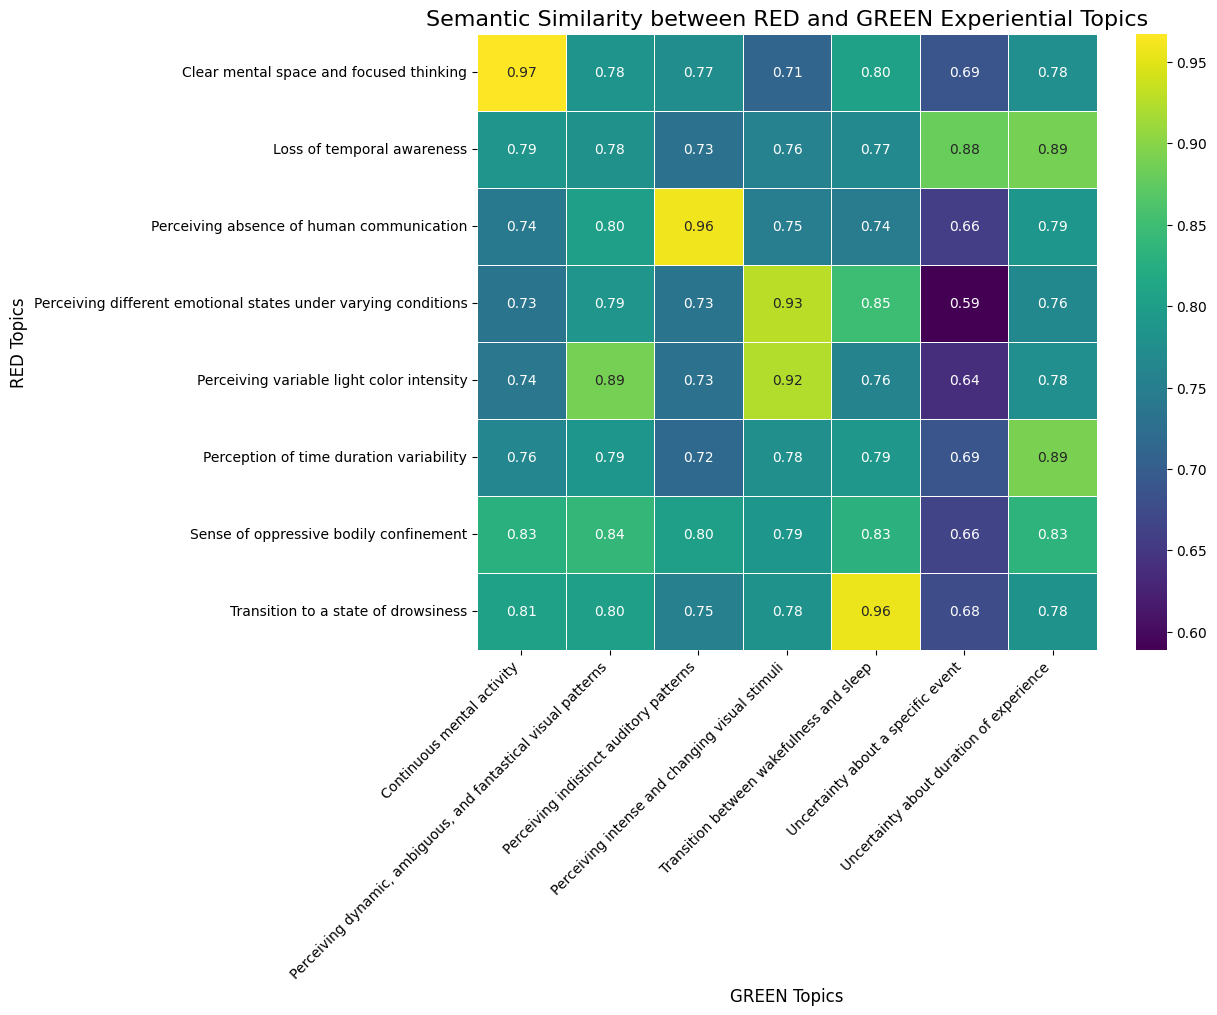

In [11]:
print("\n--- Generating Heatmap ---")

plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_matrix,
    annot=True,          # Show the similarity scores in each cell
    cmap='viridis',      # Use a color-friendly palette
    linewidths=.5,
    fmt=".2f"            # Format scores to two decimal places
)
plt.title(f'Semantic Similarity between {condition_1} and {condition_2} Experiential Topics', fontsize=16)
plt.xlabel(f'{condition_2} Topics', fontsize=12)
plt.ylabel(f'{condition_1} Topics', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()




In [12]:

# A score > threshold will be considered "shared".
SIMILARITY_THRESHOLD = 0.85  

print(f"--- Analyzing Matches with Threshold: {SIMILARITY_THRESHOLD} ---")


shared_topics = []
# Start by assuming all topics are unique
unique_df1_topics = list(similarity_matrix.index)
unique_df2_topics = list(similarity_matrix.columns)

# use a "greedy" approach: find the highest similarity pair first,
# mark those topics as "shared," and remove them from consideration.
# This helps prevent one topic from being "matched" to multiple others.

# Make a copy of the matrix to modify
matrix_copy = similarity_matrix.copy()

while True:
    # Find the absolute highest similarity score left in the matrix
    max_score = matrix_copy.max().max()
    
    # If the highest score is below our threshold, we're done
    if max_score < SIMILARITY_THRESHOLD:
        print("\nNo more matches found above threshold.")
        break
        
    # Find the (HS, DL) topic pair for this max score.
    # .stack() turns the DataFrame into a Series with a (row, col) MultiIndex.
    # .idxmax() finds the (row, col) index pair for the highest value.
    df1_topic, df2_topic = matrix_copy.stack().idxmax()
    score = max_score

    shared_topics.append((df1_topic, df2_topic, score))
    
    # Remove these topics from our "unique" lists
    if df1_topic in unique_df1_topics:
        unique_df1_topics.remove(df1_topic)
    if df2_topic in unique_df2_topics:
        unique_df2_topics.remove(df2_topic)
    
    # "Remove" these topics from the matrix so they aren't matched again

    matrix_copy.loc[df1_topic, :] = 0
    matrix_copy.loc[:, df2_topic] = 0
    
    print(f"Found Match: {df1_topic} ({condition_1}) <-> {df2_topic} ({condition_2}) | Score: {score:.3f}")




print("\n\n--- Analysis Complete ---")

print(f"\n **Shared Topic Pairs (Score > {SIMILARITY_THRESHOLD}):**")
if shared_topics:
    for cond1, cond2, score in shared_topics:
        print(f"  * {condition_1}: '{cond1}'  <->  {condition_2}: '{cond2}' (Similarity: {score:.3f})")
else:
    print("  No shared topics found with this threshold.")
    
print(f"\n**Unique {condition_1} Topics (No match in {condition_2}):**")
if unique_df1_topics:
    for topic in unique_df1_topics:
        print(f"  * {topic}")
else:
    print(f"  No unique {condition_1} topics found.")

print(f"\n**Unique {condition_2} Topics (No match in {condition_1}):**")
if unique_df2_topics:
    for topic in unique_df2_topics:
        print(f"  * {topic}")
else:
    print(f"  No unique {condition_2} topics found.")

--- Analyzing Matches with Threshold: 0.85 ---
Found Match: Clear mental space and focused thinking (RED) <-> Continuous mental activity (GREEN) | Score: 0.967
Found Match: Perceiving absence of human communication (RED) <-> Perceiving indistinct auditory patterns (GREEN) | Score: 0.959
Found Match: Transition to a state of drowsiness (RED) <-> Transition between wakefulness and sleep (GREEN) | Score: 0.956
Found Match: Perceiving different emotional states under varying conditions (RED) <-> Perceiving intense and changing visual stimuli (GREEN) | Score: 0.928
Found Match: Perception of time duration variability (RED) <-> Uncertainty about duration of experience (GREEN) | Score: 0.892
Found Match: Perceiving variable light color intensity (RED) <-> Perceiving dynamic, ambiguous, and fantastical visual patterns (GREEN) | Score: 0.888
Found Match: Loss of temporal awareness (RED) <-> Uncertainty about a specific event (GREEN) | Score: 0.881

No more matches found above threshold.


--- A

In [13]:
# Create a merged contingency table that combines paired HS↔DL topics and preserves unpaired topics.
# Assumes these variables already exist in the notebook: shared_topics, hs_counts, dl_counts, unique_hs_topics, unique_dl_topics, results_dir

rows = []

# Add paired topics (from shared_topics: list of (hs_topic, dl_topic, score))
for df1_topic, df2_topic, score in shared_topics:
    rows.append({
        "theme": f"{df1_topic} / {df2_topic}",
        "cond1_topic": df1_topic,
        "cond2_topic": df2_topic,
        f"{condition_1}": int(cond1_counts.get(df1_topic, 0)),
        f"{condition_2}": int(cond2_counts.get(df2_topic, 0)),
        "type": "paired",
        "cosine": float(score),
    })

# Add HS-specific (unmatched) topics
matched_cond1 = {cond1 for cond1, cond1, _ in shared_topics}
for cond1 in unique_df1_topics:
    if cond1 in matched_cond1:
        continue
    rows.append({
        "theme": cond1,
        "cond1_topic": cond1,
        "cond2_topic": "N/A",
        f"{condition_1}": int(cond1_counts.get(cond1)),
        f"{condition_2}": 0,
        "type": f"{condition_1}-specific",
        "cosine": float("nan"),
    })

# Add DL-specific (unmatched) topics
matched_cond2 = {cond2 for cond1, cond2, _ in shared_topics}
for cond2 in unique_df2_topics:
    if cond2 in matched_cond2:
        continue
    rows.append({
        "theme": cond2,
        "cond1_topic": "N/A",
        "cond2_topic": cond2,
        f"{condition_1}": 0,
        f"{condition_2}": int(cond2_counts.get(cond2, 0)),
        "type": f"{condition_2}-specific",
        "cosine": float("nan"),
    })

merged_contingency = pd.DataFrame(rows).set_index("theme")[["cond1_topic", "cond2_topic", f"{condition_1}", f"{condition_2}", "type", "cosine"]]

# sort by total counts (HS+DL) descending for readability
merged_contingency["total"] = merged_contingency[f"{condition_1}"] + merged_contingency[f"{condition_2}"]
merged_contingency = merged_contingency.sort_values("total", ascending=False).drop(columns="total")

# show and save
print(merged_contingency)
merged_contingency.to_csv(os.path.join(results_dir, "merged_contingency_table.csv"))

                                                                                          cond1_topic  \
theme                                                                                                   
Transition to a state of drowsiness / Transitio...                Transition to a state of drowsiness   
Perceiving different emotional states under var...  Perceiving different emotional states under va...   
Perceiving variable light color intensity / Per...          Perceiving variable light color intensity   
Perceiving absence of human communication / Per...          Perceiving absence of human communication   
Clear mental space and focused thinking / Conti...            Clear mental space and focused thinking   
Loss of temporal awareness / Uncertainty about ...                         Loss of temporal awareness   
Perception of time duration variability / Uncer...            Perception of time duration variability   
Sense of oppressive bodily confinement                 

In [14]:
merged_contingency

,cond1_topic,cond2_topic,RED,GREEN,type,cosine
theme,,,,,,
Transition to a state of drowsiness / Transition between wakefulness and sleep,Transition to a state of drowsiness,Transition between wakefulness and sleep,37,47,paired,0.955741
Perceiving different emotional states under varying conditions / Perceiving intense and changing visual stimuli,Perceiving different emotional states under va...,Perceiving intense and changing visual stimuli,29,55,paired,0.927787
"Perceiving variable light color intensity / Perceiving dynamic, ambiguous, and fantastical visual patterns",Perceiving variable light color intensity,"Perceiving dynamic, ambiguous, and fantastical...",51,18,paired,0.888316
Perceiving absence of human communication / Perceiving indistinct auditory patterns,Perceiving absence of human communication,Perceiving indistinct auditory patterns,39,25,paired,0.958946
Clear mental space and focused thinking / Continuous mental activity,Clear mental space and focused thinking,Continuous mental activity,29,28,paired,0.967158
Loss of temporal awareness / Uncertainty about a specific event,Loss of temporal awareness,Uncertainty about a specific event,30,13,paired,0.881375
Perception of time duration variability / Uncertainty about duration of experience,Perception of time duration variability,Uncertainty about duration of experience,17,21,paired,0.891735
Sense of oppressive bodily confinement,Sense of oppressive bodily confinement,N/A,27,0,RED-specific,NaN


--- Chi-Squared Test Results ---
Chi-squared statistic (χ²): 57.15
Degrees of Freedom (dof): 7
P-value: 0.0000

--- Interpretation ---
The p-value (0.0000) is less than 0.05, indicating a statistically significant association
between the condition (RED/GREEN) and the experiential themes reported.


--- Generating Final Bar Chart ---


/var/folders/1d/q_0fy53s0jdcsc1sb09wkntw00z7v7/T/ipykernel_7369/1630403356.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(formatted_labels)



Chart saved as /Users/rb666/Projects/MOSAIC/results/topic_frequency_comparison.png
Chart saved as /Users/rb666/Projects/MOSAIC/results/topic_frequency_comparison.pdf


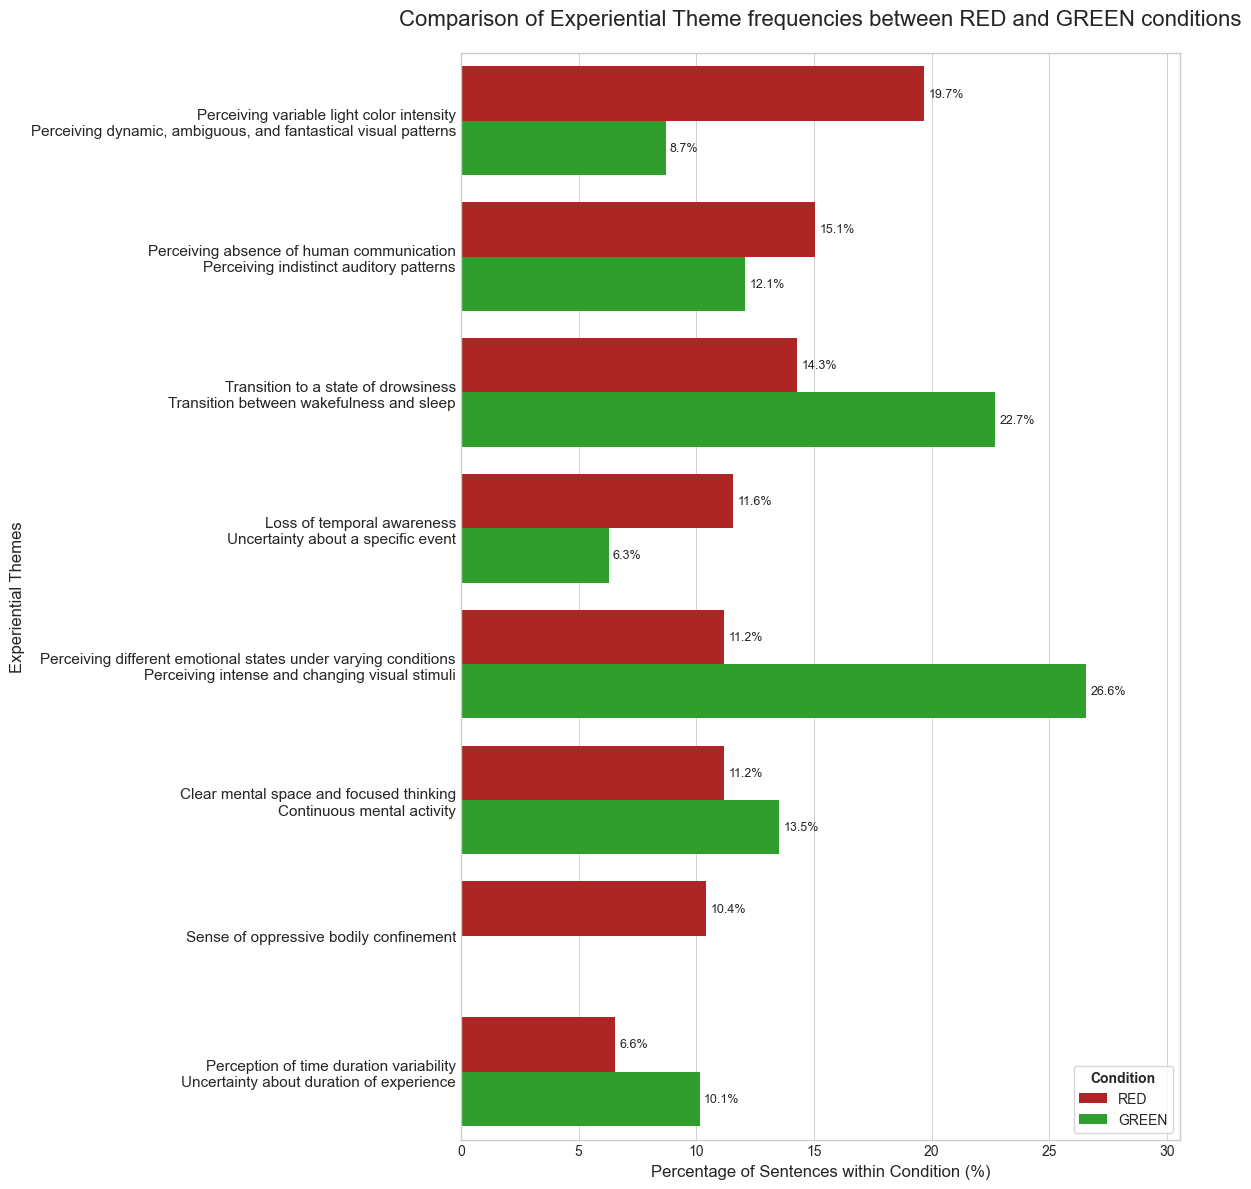

In [15]:
# %% [markdown]
# ### 4. Final Frequency Comparison Chart (Formatted)
# 
# This code generates the final comparative bar chart.
# It now formats merged topic labels onto two lines for readability.

# %%
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Prepare Data for Test ---
# We only need the raw counts for the Chi-Squared test.
# The 'merged_contingency' DataFrame should exist from the previous cell.
counts_df = merged_contingency[[f'{condition_1}', f'{condition_2}']]

# --- Step 2: Perform the Chi-Squared Test ---

print("--- Chi-Squared Test Results ---")
# Check if there are at least 2 topics to compare
if counts_df.shape[0] >= 2 and counts_df.shape[1] >= 2:
    try:
        chi2, p_value, dof, expected = chi2_contingency(counts_df)
        print(f"Chi-squared statistic (χ²): {chi2:.2f}")
        print(f"Degrees of Freedom (dof): {dof}")
        print(f"P-value: {p_value:.4f}")

        # --- Interpretation ---
        print("\n--- Interpretation ---")
        alpha = 0.05
        if p_value < alpha:
            print(f"The p-value ({p_value:.4f}) is less than {alpha}, indicating a statistically significant association")
            print(f"between the condition ({condition_1}/{condition_2}) and the experiential themes reported.")
        else:
            print(f"The p-value ({p_value:.4f}) is not less than {alpha}, indicating no statistically significant association.")
    except ValueError as e:
        print(f"Could not perform Chi-Squared test. Error: {e}")
        print(f"This can happen if one condition ({condition_1} or {condition_2}) has a sum of 0.")
else:
    print("Not enough data to perform a Chi-Squared test (need at least 2 rows and 2 columns).")
    
print("\n" + "="*50 + "\n")


# --- Step 3: Create the Comparative Bar Chart ---

print("--- Generating Final Bar Chart ---")

# Calculate percentages within each condition to normalise for sample size
percentage_table = counts_df.div(counts_df.sum(axis=0), axis=1) * 100

# Sort the topics by the percentage in the HS condition
percentage_table_sorted = percentage_table.fillna(0)
sorted_order = percentage_table_sorted.sort_values(by=f'{condition_1}', ascending=False).index

# *** NEW: Create formatted labels for the y-axis ***
# This replaces " / " with a newline character ("\n")
formatted_labels = [label.replace(' / ', '\n') for label in sorted_order]

# Prepare the data for plotting by "melting" the dataframe
plot_data = percentage_table.reset_index().melt(
    id_vars='theme', 
    var_name='Condition', 
    value_name='Percentage'
)

# --- Create the Plot (Styled like your example image) ---
plt.style.use('seaborn-v0_8-whitegrid')
# *** UPDATED: Increased figure height for two-line labels ***
fig, ax = plt.subplots(figsize=(12, 12)) 

# Use the exact colors from your example chart
# palette_colors = {f'{condition_1}': "#6d1f9d", f'{condition_2}': "#ffa41c"} # Purple / Orange
palette_colors = {f'{condition_1}': "#c40e0e", f'{condition_2}': "#1db11a"} # Purple / Orange

sns.barplot(
    data=plot_data,
    y='theme',           
    x='Percentage',
    hue='Condition',
    palette=palette_colors,
    order=sorted_order,  # This still correctly orders the data
    ax=ax
)

# *** NEW: Apply the formatted, two-line labels to the y-axis ***
ax.set_yticklabels(formatted_labels)

# --- Formatting (to match your example) ---
ax.set_title(f'Comparison of Experiential Theme frequencies between {condition_1} and {condition_2} conditions', fontsize=16, pad=20)
ax.set_xlabel('Percentage of Sentences within Condition (%)', fontsize=12)
ax.set_ylabel('Experiential Themes', fontsize=12)
ax.tick_params(axis='y', labelsize=11) # Y-axis labels
ax.grid(axis='y', which='both', linestyle='',alpha=0) # Remove horizontal gridlines
ax.grid(axis='x', which='major', linestyle='-', linewidth=0.5, color='grey', alpha=0.5) # Keep vertical gridlines


# Format legend
legend = ax.legend(title='Condition', loc='lower right', frameon=True, facecolor='white', shadow=False)
legend.get_title().set_fontweight('bold')

# Add percentage labels to the bars
for container in ax.containers:
    # Filter out 0% labels to avoid clutter
    labels = [f'{v:.1f}%' if v > 0 else '' for v in container.datavalues]
    ax.bar_label(
        container, 
        labels=labels, 
        label_type='edge', 
        fontsize=9, 
        padding=3
    )

# Adjust x-axis limit to give space for labels
max_percentage = plot_data['Percentage'].max()
ax.set_xlim(0, max_percentage * 1.15) 

plt.tight_layout()

# Save the figure
save_path = os.path.join(results_dir, "topic_frequency_comparison.png")
plt.savefig(save_path, dpi=300)
print(f"\nChart saved as {save_path}")

pdf_save_path = os.path.join(results_dir, "topic_frequency_comparison.pdf")
plt.savefig(pdf_save_path, format='pdf', bbox_inches='tight')
print(f"Chart saved as {pdf_save_path}")

# Show the plot
plt.show()

--- Chi-Squared Test Results ---
Chi-squared statistic (χ²): 57.15
Degrees of Freedom (dof): 7
P-value: 0.0000

--- Interpretation ---
The p-value (0.0000) is less than 0.05, indicating a statistically significant association
between the condition (RED/GREEN) and the experiential themes reported.


--- Generating Final Bar Chart ---


/var/folders/1d/q_0fy53s0jdcsc1sb09wkntw00z7v7/T/ipykernel_7369/1010230523.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(formatted_labels)



Chart saved as /Users/rb666/Projects/MOSAIC/results/topic_frequency_comparison.png
Chart saved as /Users/rb666/Projects/MOSAIC/results/topic_frequency_comparison.pdf


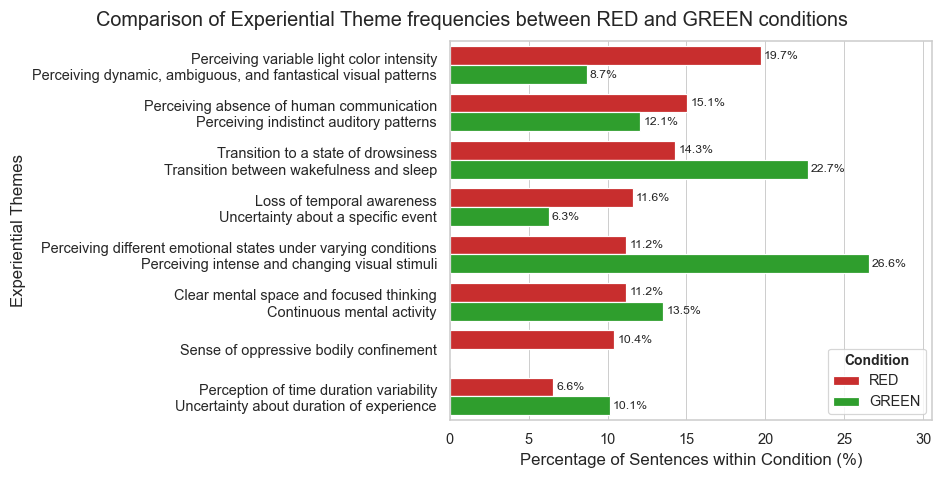

In [16]:
import os
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# --- Display & export tweaks ---
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=0.95)
rcParams["figure.dpi"] = 110
rcParams["savefig.dpi"] = 600
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42

# --- Step 1: Prepare Data for Test ---
counts_df = merged_contingency[[condition_1, condition_2]]

# --- Step 2: Perform the Chi-Squared Test ---
print("--- Chi-Squared Test Results ---")
if counts_df.shape[0] >= 2 and counts_df.shape[1] >= 2:
    try:
        chi2, p_value, dof, expected = chi2_contingency(counts_df)
        print(f"Chi-squared statistic (χ²): {chi2:.2f}")
        print(f"Degrees of Freedom (dof): {dof}")
        print(f"P-value: {p_value:.4f}")

        print("\n--- Interpretation ---")
        alpha = 0.05
        if p_value < alpha:
            print(f"The p-value ({p_value:.4f}) is less than {alpha}, indicating a statistically significant association")
            print(f"between the condition ({condition_1}/{condition_2}) and the experiential themes reported.")
        else:
            print(f"The p-value ({p_value:.4f}) is not less than {alpha}, indicating no statistically significant association.")
    except ValueError as e:
        print(f"Could not perform Chi-Squared test. Error: {e}")
        print(f"This can happen if one condition ({condition_1} or {condition_2}) has a sum of 0.")
else:
    print("Not enough data to perform a Chi-Squared test (need at least 2 rows and 2 columns).")

print("\n" + "="*50 + "\n")

# --- Step 3: Create the Comparative Bar Chart ---
print("--- Generating Final Bar Chart ---")

percentage_table = counts_df.div(counts_df.sum(axis=0), axis=1) * 100

percentage_table_sorted = percentage_table.fillna(0)
sorted_order = percentage_table_sorted.sort_values(by=condition_1, ascending=False).index

formatted_labels = [label.replace(' / ', '\n') for label in sorted_order]

plot_data = percentage_table.reset_index().melt(
    id_vars='theme',
    var_name='Condition',
    value_name='Percentage'
)

n_topics = len(sorted_order)
height_per_row = 0.38
min_h, max_h = 4.0, 9.0
fig_h = min(max(min_h, n_topics * height_per_row + 1.2), max_h)

fig, ax = plt.subplots(figsize=(8.5, fig_h))

# palette_colors = {condition_1: "#6d1f9d", condition_2: "#ffa41c"}
palette_colors = {f'{condition_1}': "#e11515", f'{condition_2}': "#1db11a"} # Purple / Orange

sns.barplot(
    data=plot_data,
    y='theme',
    x='Percentage',
    hue='Condition',
    palette=palette_colors,
    order=sorted_order,
    ax=ax
)

ax.set_yticklabels(formatted_labels)

fig.suptitle(
    f'Comparison of Experiential Theme frequencies between {condition_1} and {condition_2} conditions',
    fontsize=13, y=0.995, ha='center'
)
plt.tight_layout(rect=[0, 0, 1, 0.96])

ax.set_xlabel('Percentage of Sentences within Condition (%)', fontsize=11)
ax.set_ylabel('Experiential Themes', fontsize=11)
ax.tick_params(axis='y', labelsize=9.5)
ax.tick_params(axis='x', labelsize=9.5)
ax.grid(axis='y', which='both', linestyle='', alpha=0)
ax.grid(axis='x', which='major', linestyle='-', linewidth=0.5, color='grey', alpha=0.5)

legend = ax.legend(title='Condition', loc='lower right', frameon=True, facecolor='white', shadow=False)
legend.get_title().set_fontweight('bold')
for text in legend.get_texts():
    text.set_fontsize(9.5)

for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 0 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='edge', fontsize=8, padding=2)

max_percentage = float(plot_data['Percentage'].max()) if len(plot_data) else 0
ax.set_xlim(0, max_percentage * 1.15)

plt.tight_layout(pad=0.5)

png_path = os.path.join(results_dir, "topic_frequency_comparison.png")
pdf_path = os.path.join(results_dir, "topic_frequency_comparison.pdf")

plt.savefig(png_path, dpi=600, bbox_inches='tight', pad_inches=0.05, facecolor='white')
print(f"\nChart saved as {png_path}")

plt.savefig(pdf_path, format='pdf', bbox_inches='tight', pad_inches=0.05)
print(f"Chart saved as {pdf_path}")

plt.show()